# Event state segmentation (GSBS)

**Contributors: James Antony. GSBS code by Linda Geerligs from Geerligs et al., 2021 (https://www.sciencedirect.com/science/article/pii/S1053811921003621).**  

### Goals
 1. Run neural event state segmentation using GSBS (Fig 5A-B)
 2. Validate against experimenter- + participant-defined boundaries (Fig 5C)
 3. Correlate boundary strength/likelihood and weighted path length between successive events (Fig 5D-E)

### Inputs 
 1. Event boundary + fMRI data from ROI/parcel
 2. SRM-ified neural data
 
### Outputs 
 1. Save timecourses of state transitions and transition data w.r.t event boundaries for later alignment
 2. Save SubGSBSAng / others for main correlations

In [5]:
## note: need to re-run on parcels w/ 350 states!
#ROIs = ['V1','vmPFC','precun','ang','PMC','A1','HC','antHC','postHC']
ROIs = ['V1','vmPFC','ang','PMC','postHC','antHC']
#ROIs = ['postHC','antHC']
nR=len(ROIs)
gp=1                 #which group (1=select ROIs,4=parcels)
roin=2               #which ROI
runavg=0             #run GSBS on average data (first collapsed across subjects)
runall=0             #run GSBS on each subject (note: takes several hours)
sv=1                 #save data after running GSBS (only applicable if one of the above is 1)
raw_or_srm_or_emb=2  #run on raw (1; never--takes too long) or SRM (2; do this)
plotavg=1            #regardless of running, will we plot the data?
plot_sv=1            #save plots?
test_binary=0        #use binary presence of EB rather than strength
maxk=350             #max # event states
    
subs=['01','02','03','04','05','06','07','08','09','10','11','12',
      '13','14','15','16','19','20','21','23','24','25','26']
nS=len(subs)
print('nS =',nS)
fr_TR=2

import os
import time
import math
import copy
import scipy.io
import matplotlib
import numpy as np
import pandas as pd 
import numpy.ma as ma
import seaborn as sns 
from scipy import stats
from nilearn import image
from nilearn import datasets
import matplotlib.pyplot as plt
from statesegmentation import GSBS
import matplotlib.patches as patches
from nilearn.image import resample_to_img
from statsmodels.stats.multitest import fdrcorrection
from scipy.stats import ttest_ind, ttest_rel, ttest_1samp, pearsonr
from mpl_toolkits.axes_grid1 import make_axes_locatable
from nilearn.maskers import NiftiMasker, NiftiLabelsMasker

#preset variables
from fr_utils import fr_dir, fr_bids_dir
results_path=fr_bids_dir+'derivatives/secondlevel/'
firstlevel_dir=fr_bids_dir+'derivatives/firstlevel/'
analysis_dir=fr_dir+'analysis/'
roi_dir=fr_dir+'bids/RangaL/RangaL_Antony/rois/'
ses='ses-01'
dir_out = results_path + 'states/'
fs1=10

print('ROI dir: %s' %roi_dir)
all_edges=np.load('pydata/all_edges.npy',allow_pickle=True)
all_edges_tr=np.load('pydata/all_edges_tr.npy',allow_pickle=True)
all_edges_st_tr=np.load('pydata/all_edges_st_tr.npy',allow_pickle=True)
all_edges_em_tr=np.load('pydata/all_edges_em_tr.npy',allow_pickle=True)
all_edges_emo_tr=np.load('pydata/all_edges_emo_tr.npy',allow_pickle=True)
all_edges_sp_tr=np.load('pydata/all_edges_sp_tr.npy',allow_pickle=True)

nS = 23
ROI dir: /Users/jamesantony/Desktop/friends_fmri/data/bids/RangaL/RangaL_Antony/rois/


In [6]:
def hist_plot(dat,dat_s,xl,fn):
    fos=30
    f, ax = plt.subplots(1,1, figsize=(9,3))
    hdat=ax.hist(dat_s,hbins,color='r')
    ax.vlines(dat,0,np.max(hdat[0]),'k',linewidth=3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False) 
    ax.set_ylabel('Count',fontsize=fos,color='black')
    ax.set_xlabel(xl,fontsize=fos,color='black')
    ax.tick_params(axis='both', which='major',labelsize=fos*2/3,colors='black')
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(2)
    print('%s, rank %s:' %(xl,stats.percentileofscore(dat_s,dat)))
    f.tight_layout()
    if plot_sv:
        plt.savefig(fn, transparent=True)

def ccf_values(series1, series2): #cross-correlation function from: https://www.datainsightonline.com/post/cross-correlation-with-two-time-series-in-python
    p = series1
    q = series2
    p = (p - np.mean(p)) / (np.std(p) * len(p))
    q = (q - np.mean(q)) / (np.std(q))  
    c = np.correlate(p, q, 'full')
    return c

def smooth_corr(d1,d2,txt,outp):
    fill=ma.corrcoef(ma.masked_invalid(d1), ma.masked_invalid(d2))
    smc=fill[1,0] #smoothed correlation
    if outp:
        print(txt+' r agreement: %s' %smc)
    return smc

#plot 2-D matrices and predicted boundaries (true # of possessions) 
def plot_tt_similarity_matrix(ax,data_matrix,data_matrix2,bounds,sec_bounds,bounds_true,npts):
    if len(data_matrix2)>0:
        twodmat=fishr2z2d(data_matrix.T,data_matrix2.T)
    else:
        twodmat=fishr2z2d(data_matrix.T,[])
    im=ax.imshow(twodmat, cmap='viridis',vmin=-1,vmax=1)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(lw9)
    # plot predicted boundaries 
    if len(bounds)>0:
        bounds_aug = np.concatenate(([0],bounds,[npts]))
        for i in range(len(bounds_aug)-1):
            rect = patches.Rectangle(
                (bounds_aug[i]-0.5,bounds_aug[i]-0.5),
                bounds_aug[i+1]-bounds_aug[i],
                bounds_aug[i+1]-bounds_aug[i],
                linewidth=lw9,edgecolor='w',facecolor='none')
            ax.add_patch(rect)
    if len(sec_bounds)>0:
        bounds_aug = np.concatenate(([0],sec_bounds,[npts]))
        for i in range(len(bounds_aug)-1):
            rect = patches.Rectangle(
                (bounds_aug[i],bounds_aug[i]),
                bounds_aug[i+1]-bounds_aug[i],
                bounds_aug[i+1]-bounds_aug[i],
                linewidth=lw9-1,edgecolor='y',facecolor='none')
            ax.add_patch(rect)
    if len(bounds_true)>0:
        bounds_aug = np.concatenate(([0],bounds_true,[npts]))
        for i in range(len(bounds_aug)-1):
            rect = patches.Rectangle(
                (bounds_aug[i],bounds_aug[i]),
                bounds_aug[i+1]-bounds_aug[i],
                bounds_aug[i+1]-bounds_aug[i],
                linewidth=lw9-2,edgecolor='r',facecolor='none')
            ax.add_patch(rect)
    return twodmat,im

def fishr2z2d(dat,dat2):
    if len(dat2)==0:
        rs=np.corrcoef(dat)
        for m in range(rs.shape[0]): #r-to-z transform
            for n in range(rs.shape[0]):
                rs[m,n]=np.multiply((np.log([1+rs[m,n]])-np.log([1-rs[m,n]])),0.5)
                if m==n:
                    rs[m,n]=0 #blank out diagonal
    else:
        evs=dat.shape[0]
        rs=np.zeros((evs,evs))
        for v in range(evs):
            for vv in range(evs):
                fill=np.corrcoef(dat[v,:],dat2[vv,:])
                rs[v,vv]=fill[1,0]#first of new event, last of old one
        print('shape rs:',rs.shape)
        for m in range(rs.shape[0]): #r-to-z transform
            for n in range(rs.shape[0]):
                rs[m,n]=np.multiply((np.log([1+rs[m,n]])-np.log([1-rs[m,n]])),0.5)
    return rs

#function for running mean
def running_mean(x,N,shift):
    rm=np.zeros((x.shape[0]))
    for i in range(0,len(x)):
        if i<N+shift:
            rm[i]=np.mean(x[0:(i+N)+shift+1])
        elif i>len(x)-1-N+shift:
            rm[i]=np.mean(x[(i-N)+shift:len(x)-1+1]) #only forwards
        else:
            rm[i]=np.mean(x[(i-N)+shift:(i+N)+shift+1])
    return rm

def fishr2z(d,d2):
    rval=pearsonr(d,d2)[0]
    d=np.multiply((np.log(1+rval)-np.log(1-rval)),0.5)
    return d

In [7]:
if gp==4:
    nR=100
    dataset=datasets.fetch_atlas_schaefer_2018(n_rois=nR,resolution_mm=2,yeo_networks=7)
    ROIs=dataset.labels
    i=np.eye(3)*2 #identity matrix to resample to 3 mm isometric voxels
    dataset.maps=image.resample_img(dataset.maps, target_affine=i,interpolation='nearest') #resample
    masker_ho=NiftiLabelsMasker(labels_img=dataset.maps) #parcel labels
    index=masker_ho.labels_img.dataobj

In [8]:
fn=analysis_dir+'lum_mot_all.mat'
mat_contents = scipy.io.loadmat(fn)
mot_tc = mat_contents['mot_tr']
mot_tc_thr = mat_contents['mot_tr_thr']
fn=analysis_dir+'upperAud_tr.mat'
mat_contents = scipy.io.loadmat(fn)
aud_tc = mat_contents['upper_tr']
if not os.path.exists(dir_out): #create directory if it doesn't exist
    os.makedirs(dir_out)
    
print('visual motion timecourse shape: %s, %s (needs pad)' %(mot_tc.shape))
print('auditory envelope timecourse shape: %s, %s (needs pad)' %(aud_tc.shape))

T=mot_tc.shape[0]+3

all_edges_tc_tr,all_edges_st_tc_tr=np.zeros((T)),np.zeros((T))
all_edges_tc_tr[all_edges_tr]=1
all_edges_st_tc_tr[all_edges_st_tr]=1
all_edges_emo_tr=all_edges_em_tr-all_edges_sp_tr #event model change only
all_edges_emo_tr[np.where(all_edges_emo_tr<0)[0]]=0 #zero out negative stdmat

evseg_tc1=np.load('pydata/tc_m_tr1.npy')
evseg_tc2=np.load('pydata/tc_m_tr2.npy')
print(evseg_tc1.shape)
print(all_edges_tc_tr.shape)

#pad last few TRs of motion/luminance to align w/ TRs
tr_diff=T-len(mot_tc)
mot_tc=np.vstack((mot_tc,np.zeros((tr_diff,1))))
mot_tc=mot_tc[:,0]
mot_tc_thr=np.vstack((mot_tc_thr,np.zeros((tr_diff,1))))
mot_tc_thr=mot_tc_thr[:,0]
aud_tc=np.vstack((aud_tc,np.zeros((tr_diff,1))))
aud_tc=aud_tc[:,0]

scut=10
for roin in range(nR):#nR
    print(ROIs[roin])
    sn='pydata/view-' + str(ROIs[roin]) + '_postSRM_'+str(scut)+'.npy'
    if gp==4:
        sn='pydata/view-'+str(gp)+'-'+str(ROIs[roin])+'_postSRM_'+str(scut)+'.npy'
    curr_test_obj=np.load(sn)
    for i in range(nS):
        if i==0:
            bold_roi_a=np.zeros((nS,curr_test_obj.shape[0],curr_test_obj.shape[1])) #subs x TRs x voxels
        bold_roi_a[i,:,:]=curr_test_obj[:,:,i]
    print(bold_roi_a.shape)
    T=bold_roi_a.shape[1]

    fn='pydata/GSBS_m_a-'+str(ROIs[roin])+'-'+str(raw_or_srm_or_emb)+'-'+str(bold_roi_a.shape[2])+'.npy'
    mm=np.mean(bold_roi_a,axis=0) #mean across subjects
    print('mm shape:',mm.shape)
    GSBS_states_m_obj=[]
    if runavg:
        print('Testing up to %s states' %maxk)
        GSBS_states_m = GSBS(x = mm, kmax = maxk)
        GSBS_states_m.fit()
        GSBS_states_m_obj.append(GSBS_states_m)
        if sv:
            np.save(fn,GSBS_states_m_obj)
    else:
        GSBS_states_m=np.load(fn,allow_pickle=True)

    #run on all subs - LONG step, multiple hours
    if runall:
        fn='pydata/GSBS_a-'+str(ROIs[roin])+'-'+str(raw_or_srm_or_emb)+'-'+str(bold_roi_a.shape[2])+'.npy'
        if os.path.exists(fn):#+'ZZ'
            print('file exists!')
        else:
            GSBS_states_a=[]
            for sub in range(nS):
                #if you need need to load prior values!
                print(sub)
                t1=time.perf_counter()/60
                sub_bold=bold_roi_a[sub,:,:] #temp - comment this
                GSBS_states = GSBS(x = sub_bold, kmax = maxk)
                GSBS_states.fit()
                t2=time.perf_counter()/60
                print('GSBS took %s minutes.' %(t2-t1))
                GSBS_states_a.append(GSBS_states)
            if sv:
                np.save(fn,GSBS_states_a)

visual motion timecourse shape: 1260, 1 (needs pad)
auditory envelope timecourse shape: 1260, 1 (needs pad)
(1263,)
(1263,)
V1
(23, 1263, 37)
mm shape: (1263, 37)
vmPFC
(23, 1263, 20)
mm shape: (1263, 20)
ang
(23, 1263, 31)
mm shape: (1263, 31)
PMC
(23, 1263, 29)
mm shape: (1263, 29)
postHC
(23, 1263, 23)
mm shape: (1263, 23)
antHC
(23, 1263, 5)
mm shape: (1263, 5)


# plot+compute GSBS alignments (based on running it above)

In [9]:
#run on multiple subjects?
multsubs=1 #1=run across subs, 0=don't
sn='pydata/view-' + str(ROIs[roin]) + '_postSRM_'+str(scut)+'.npy'
if gp==4:
    sn='pydata/view-'+str(gp)+'-'+str(ROIs[roin])+'_postSRM_'+str(scut)+'.npy'
curr_test_obj=np.load(sn)
print(curr_test_obj.shape)
#GSBS run on every subject, time courses collapsed below
ln='pydata/GSBS_a-'+str(ROIs[roin])+'-'+str(raw_or_srm_or_emb)+'-'+str(curr_test_obj.shape[1])+'.npy'
GSBS_states_a=np.load(ln,allow_pickle=True)
smoothf=2
smoothshift=0 #shift from 0? (unused) (0)
plotind=0 #make plots for individual subject / grand average
plotind2=0 #make plots for individual subject / grand average
printind=0 #print out results from individual subjects / grand average
lw9,fos=5,50
if multsubs:    
    print(roin)
    for sub in range(nS):
        #load in data
        print(sub)
        GSBS_states_sub=GSBS_states_a[sub]
        sub_bold=bold_roi_a[sub,:,:]
        
        #GSBS boundary order vs. strength
        #obtaining GSBS event bounds for the optimal number of events
        GSBS_bounds = np.where(GSBS_states_sub.deltas)[0]
        best_s=np.max(GSBS_states_sub.nstates) #best-fitting # of states
        GSBS_bounds_by_tr = np.where(GSBS_states_sub.get_deltas(best_s))[0] #gives location of boundaries for given # states
        print('GSBS boundaries by TR: %s' %GSBS_bounds_by_tr)
        GSBS_bounds_by_sec=GSBS_bounds_by_tr*2
        GSBS_bound_tc=np.zeros((T))
        GSBS_bound_tc[GSBS_bounds_by_tr]=GSBS_states_sub.strengths[GSBS_bounds_by_tr] #weight by strength of boundary!
        if test_binary:
            GSBS_bound_tc[GSBS_bounds_by_tr]=1 #
        
        if plotind:
            pts=400
            f, ax = plt.subplots(1,1, figsize = (15,15))
            exmat,im=plot_tt_similarity_matrix(ax, sub_bold[:pts,:pts].T,[], 
                                               np.divide(all_edges,fr_TR),[],GSBS_bounds_by_tr,T)
            f.tight_layout()
            fn="figs/Event_GSBS_simmat-"+str(ROIs[roin])+"-"+str(raw_or_srm_or_emb)+"-"+str(bold_roi_a.shape[2])+'_'+str(i)+'.pdf'
            if plot_sv:
                plt.savefig(fn, transparent=True)
            title_text = '''TR-TR correlation matrix, %s''' %ROIs[roin]
            ax.set_title(title_text)
            f.colorbar(im, orientation='vertical')
        
        lmt,nb,j=5,len(GSBS_bounds_by_tr),0
        rge=np.linspace(-lmt,lmt,lmt*2+1)

        dat=np.zeros((len(all_edges_tr),len(rge)))
        for i in range(len(all_edges_tr)):
            curr=all_edges_tr[i]
            if np.logical_and(curr>=lmt,curr<len(GSBS_bound_tc)-lmt+1):
                dat[j,:]=GSBS_bound_tc[curr-lmt:curr+lmt+1]
                j+=1
        if plotind2:
            print(np.sum(dat,axis=1))
            f, ax = plt.subplots(1,1, figsize = (10,3))
            x,y,err=rge,np.sum(dat,axis=0),np.std(dat,axis=0)
            ax.errorbar(rge,np.sum(dat,axis=0),np.std(dat,axis=0)/np.sqrt(nb))
            ax.set_xlabel('Time (relative to GSBS boundary)')
            if quicktest==1:
                ax.set_ylabel('''Global motion moments
                above threshold''')
            elif quicktest==2:
                ax.set_ylabel('''Event boundaries''')
        
        minl=np.min([GSBS_bound_tc.shape[0],all_edges_em_tr.shape[0]])
        fill=np.corrcoef(GSBS_bound_tc[:minl],all_edges_em_tr[:minl])#[:T]
        agree_r=fill[1,0] #non-smoothed correlation
        
        sum_bounds_smooth_tc=running_mean(GSBS_bound_tc,smoothf,smoothshift) # ", but smoothed
        if sub==0:
            sum_bounds_smooth_tc_a=np.zeros((nS,len(sum_bounds_smooth_tc)))
        sum_bounds_smooth_tc_a[sub,:]=sum_bounds_smooth_tc+0
        
        smooth_agree_r=smooth_corr(sum_bounds_smooth_tc,all_edges_tc_tr,'smooth',1)
        smooth_em_agree_r=smooth_corr(sum_bounds_smooth_tc,all_edges_em_tr,'smooth em',1)
        smooth_st_agree_r=smooth_corr(sum_bounds_smooth_tc,all_edges_st_tc_tr,'smooth st',1)
        smooth_emo_agree_r=smooth_corr(sum_bounds_smooth_tc,all_edges_emo_tr,'smooth emo',1)
        smooth_mot_agree_r=smooth_corr(sum_bounds_smooth_tc,mot_tc,'smooth mot',1)
        smooth_mot_thr_agree_r=smooth_corr(sum_bounds_smooth_tc,mot_tc_thr,'smooth mot_thr',1)
        smooth_aud_agree_r=smooth_corr(sum_bounds_smooth_tc,aud_tc,'smooth aud',1)
        
        smooth_ev1_agree_r=smooth_corr(sum_bounds_smooth_tc,evseg_tc1,'smooth',1)
        smooth_ev2_agree_r=smooth_corr(sum_bounds_smooth_tc,evseg_tc2,'smooth',1)
        
        if plotind2:
            pts=200#
            pts=minl//2+0
            f, ax = plt.subplots(1,1, figsize=(15,3))
            ax.plot(sum_bounds_smooth_tc[:pts],'b')
            ax.set_ylabel('Boundary?')
            ax2=ax.twinx()
            #ax2.plot(mot_tc[:pts],'r')
            ax2.plot(all_edges_tr[:pts],'r')
            ax.set_xlabel('Sample time points')
            ax2.set_ylabel('Global motion (AU)')
            ax2.set_ylabel('All transitions')

(1263, 5, 23)
5
0
GSBS boundaries by TR: [  18   96  169  200  237  327  408  474  530  619  653  709  734  764
  803  827  870  908  967  999 1015 1019 1056 1091 1097 1163 1209 1220
 1250 1254]
smooth r agreement: -0.028983435465334863
smooth em r agreement: -0.028383405730307353
smooth st r agreement: -0.0089829077061704
smooth emo r agreement: -0.03022018311267041
smooth mot r agreement: --
smooth mot_thr r agreement: -0.009902566511381598
smooth aud r agreement: -0.0274906835134201
smooth r agreement: -0.020391352339294868
smooth r agreement: -0.026767328277955027
1
GSBS boundaries by TR: [ 106  170  261  349  410  482  515  556  603  632  762  934  972 1003
 1106 1124 1183]
smooth r agreement: 0.08773862723775361
smooth em r agreement: 0.06343970042396883
smooth st r agreement: 0.06500951847611312
smooth emo r agreement: 0.06349542536040056
smooth mot r agreement: --
smooth mot_thr r agreement: 0.04676316399889029
smooth aud r agreement: 0.01848632967555567
smooth r agreement: 0.0

In [10]:
n_ev=int(all_edges_tr.shape[0]) #for boundary analyses
wpathl=np.load('pydata/wpathl.npy') #load weighted path length
GSBS_bounds_avg_tc=np.zeros((T,nR))
sum_bounds_avg_smooth_tc,sum_bounds_avg_smooth_tc_a=np.zeros((T,nR)),np.zeros((T,nR))

smooth_agree_r,smooth_em_agree_r,smooth_st_agree_r=np.zeros((nR)),np.zeros((nR)),np.zeros((nR))
smooth_emo_agree_r,smooth_mot_agree_r,smooth_mot_thr_agree_r=np.zeros((nR)),np.zeros((nR)),np.zeros((nR))
smooth_aud_agree_r,smooth_ev1_agree_r,smooth_ev2_agree_r=np.zeros((nR)),np.zeros((nR)),np.zeros((nR))

smooth_agree_a_r,smooth_em_agree_a_r,smooth_st_agree_a_r=np.zeros((nR)),np.zeros((nR)),np.zeros((nR))
smooth_emo_agree_a_r,smooth_mot_agree_a_r,smooth_mot_thr_agree_a_r=np.zeros((nR)),np.zeros((nR)),np.zeros((nR))
smooth_aud_agree_a_r,smooth_ev1_agree_a_r,smooth_ev2_agree_a_r=np.zeros((nR)),np.zeros((nR)),np.zeros((nR))

for roi_in in range(nR):
    #load this to get curr_test_obj2 shape
    sn='pydata/view-' + str(ROIs[roi_in]) + '_postSRM_'+str(scut)+'.npy'
    if gp==4:
        sn='pydata/view-'+str(gp)+'-'+str(ROIs[roi_in])+'_postSRM_'+str(scut)+'.npy'
    curr_test_obj2=np.load(sn)
    
    #now load GSBS data
    fn='pydata/GSBS_m_a-'+str(ROIs[roi_in])+'-'+str(raw_or_srm_or_emb)+'-'+str(curr_test_obj2.shape[1])+'.npy'
    GSBS_states_m=np.load(fn,allow_pickle=True)
    GSBS_states_m=GSBS_states_m[0]
    GSBS_bounds_avg = np.where(GSBS_states_m.deltas)[0]
    best_s_avg=np.max(GSBS_states_m.nstates) #best-fitting # of states
    #print(GSBS_states_m.state_patterns.shape)
    GSBS_bounds_avg_by_tr = np.where(GSBS_states_m.get_deltas(best_s_avg))[0] #gives location of boundaries for given # states
    #print('Avg GSBS boundaries by TR: %s' %GSBS_bounds_avg_by_tr)
    GSBS_bounds_avg_by_sec=GSBS_bounds_avg_by_tr*2
    GSBS_bounds_avg_tc[GSBS_bounds_avg_by_tr,roi_in]=GSBS_states_m.strengths[GSBS_bounds_avg_by_tr] #weight by strength of boundary!
    if test_binary:
        GSBS_bounds_avg_tc[GSBS_bounds_avg_by_tr,roi_in]=1 #
    
    minl=np.min([T,all_edges_em_tr.shape[0]])
    print('TRs to use:',minl)
    
    sum_bounds_avg_smooth_tc[:,roi_in]=running_mean(GSBS_bounds_avg_tc[:,roi_in],smoothf,smoothshift) # ", but smoothed
    d0=GSBS_bounds_avg_tc[:,roi_in]
    
    smooth_agree_r[roi_in]=smooth_corr(d0,all_edges_tc_tr,'smooth',1)
    smooth_em_agree_r[roi_in]=smooth_corr(d0,all_edges_em_tr,'smooth em',1)
    smooth_st_agree_r[roi_in]=smooth_corr(d0,all_edges_st_tc_tr,'smooth st',1)
    smooth_emo_agree_r[roi_in]=smooth_corr(d0,all_edges_emo_tr,'smooth emo',1)

    smooth_mot_agree_r[roi_in]=smooth_corr(d0,mot_tc,'smooth mot',1)
    smooth_mot_thr_agree_r[roi_in]=smooth_corr(d0,mot_tc_thr,'smooth mot_thr',1)
    smooth_aud_agree_r[roi_in]=smooth_corr(d0,aud_tc,'smooth aud',1)
    smooth_ev1_agree_r[roi_in]=smooth_corr(d0,evseg_tc1,'smooth ev1',1)
    smooth_ev2_agree_r[roi_in]=smooth_corr(d0,evseg_tc2,'smooth ev2',1)
        
    if multsubs:
        #GSBS run on every subject, time courses collapsed below
        ln='pydata/GSBS_a-'+str(ROIs[roi_in])+'-'+str(raw_or_srm_or_emb)+'-'+str(curr_test_obj2.shape[1])+'.npy'
        GSBS_states_a=np.load(ln,allow_pickle=True)
        for sub in range(nS):
            #load in data
            #print(sub)
            GSBS_states_sub=GSBS_states_a[sub]
        
            GSBS_bounds = np.where(GSBS_states_sub.deltas)[0]
            best_s=np.max(GSBS_states_sub.nstates) #best-fitting # of states
            GSBS_bounds_by_tr = np.where(GSBS_states_sub.get_deltas(best_s))[0] #gives location of boundaries for given # states
            GSBS_bounds_by_sec=GSBS_bounds_by_tr*2
            GSBS_bound_tc=np.zeros((T))
            GSBS_bound_tc[GSBS_bounds_by_tr]=GSBS_states_sub.strengths[GSBS_bounds_by_tr] #weight by strength of boundary!
            if test_binary:
                GSBS_bound_tc[GSBS_bounds_by_tr]=1

            minl=np.min([GSBS_bound_tc.shape[0],all_edges_em_tr.shape[0]])
            fill=np.corrcoef(GSBS_bound_tc[:minl],all_edges_em_tr[:minl])#[:T]
            agree_r=fill[1,0] #non-smoothed correlation

            sum_bounds_smooth_tc=running_mean(GSBS_bound_tc,smoothf,smoothshift) # ", but smoothed
            if sub==0:
                sum_bounds_smooth_tc_a=np.zeros((nS,len(sum_bounds_smooth_tc)))
            sum_bounds_smooth_tc_a[sub,:]=sum_bounds_smooth_tc+0
        
        print('multsubs fitted individually, mean across')
        #already smoothed, just need to avg across subs...
        sum_bounds_avg_smooth_tc_a[:,roi_in]=np.mean(sum_bounds_smooth_tc_a,axis=0)
        d0=sum_bounds_avg_smooth_tc_a[:,roi_in] #current data, shorter
        smooth_agree_a_r[roi_in]=smooth_corr(d0,all_edges_tc_tr,'smooth',1)
        smooth_em_agree_a_r[roi_in]=smooth_corr(d0,all_edges_em_tr,'smooth em',1)
        smooth_st_agree_a_r[roi_in]=smooth_corr(d0,all_edges_st_tc_tr,'smooth st',1)
        smooth_emo_agree_a_r[roi_in]=smooth_corr(d0,all_edges_emo_tr,'smooth emo',1)

        smooth_mot_agree_a_r[roi_in]=smooth_corr(d0,mot_tc,'smooth mot',1)
        smooth_mot_thr_agree_a_r[roi_in]=smooth_corr(d0,mot_tc_thr,'smooth mot_thr',1)
        smooth_aud_agree_a_r[roi_in]=smooth_corr(d0,aud_tc,'smooth aud',1)

        smooth_ev1_agree_a_r[roi_in]=smooth_corr(d0,evseg_tc1,'smooth ev1',1)
        smooth_ev2_agree_a_r[roi_in]=smooth_corr(d0,evseg_tc2,'smooth ev2',1)
    
    #save by possession boundary!
    gsbs_bounds_avg_m=np.zeros((n_ev))
    gsbs_bounds_all_m=np.zeros((nS,n_ev))
    gsbs_int=[-3,3] #-2,2; -1,3
    for i in range(n_ev):
        fir=all_edges_tr[i]-gsbs_int[0]
        las=all_edges_tr[i]+gsbs_int[1]+1
        gsbs_bounds_avg_m[i]=np.sum(sum_bounds_avg_smooth_tc[fir:las,roi_in])
        if multsubs:
            for s in range(nS):
                gsbs_bounds_all_m[s,i]=np.sum(sum_bounds_smooth_tc_a[s,fir:las])

    fn='pydata/gsbs_bounds_avg_m-'+str(gp)+'-'+str(ROIs[roi_in])+'.npy'
    np.save(fn,gsbs_bounds_avg_m)
    print(gsbs_bounds_avg_m)
    if multsubs:
        fn='pydata/gsbs_bounds_all_m-'+str(gp)+'-'+str(ROIs[roi_in])+'.npy'
        np.save(fn,gsbs_bounds_all_m)

TRs to use: 1263
smooth r agreement: 0.03200511904140656
smooth em r agreement: 0.02664025389265393
smooth st r agreement: 0.04190700420441129
smooth emo r agreement: -0.007223546591948748
smooth mot r agreement: --
smooth mot_thr r agreement: 0.00518006298617762
smooth aud r agreement: -0.01523640777769482
smooth ev1 r agreement: 0.06347684618584437
smooth ev2 r agreement: 0.0862879327258027


/var/folders/tf/vdd5gkts7zz5byycgl6j2r0c0000gn/T/ipykernel_32737/2841684255.py:46: UserWarning: Warning: converting a masked element to nan.
  smooth_mot_agree_r[roi_in]=smooth_corr(d0,mot_tc,'smooth mot',1)


multsubs fitted individually, mean across
smooth r agreement: 0.06187954069797916
smooth em r agreement: 0.04124721637822488
smooth st r agreement: 0.06556078844307511
smooth emo r agreement: 0.016339184072855988
smooth mot r agreement: --
smooth mot_thr r agreement: 0.00721076100495693
smooth aud r agreement: -0.04864901961115229
smooth ev1 r agreement: 0.10401352891808666
smooth ev2 r agreement: 0.11787482428480327
[0.26337234 0.         0.         0.32272487 0.         0.
 0.23471905 0.         0.16089622 0.28713836 0.25712358 0.24613632
 0.29438632 0.         0.10961328 0.30145582 0.30145582 0.27947702
 0.26365128 0.20432758 0.         0.12460155 0.         0.
 0.17118307 0.31226635 0.         0.14048224 0.28495887 0.27655988
 0.         0.         0.         0.         0.27915513 0.24860082
 0.         0.25269336 0.25022028 0.25727323 0.16529761 0.
 0.18410936 0.14833034 0.25147557 0.         0.32393685 0.26918874
 0.26918874 0.12910157 0.         0.        ]
TRs to use: 1263
smoo

/var/folders/tf/vdd5gkts7zz5byycgl6j2r0c0000gn/T/ipykernel_32737/2841684255.py:88: UserWarning: Warning: converting a masked element to nan.
  smooth_mot_agree_a_r[roi_in]=smooth_corr(d0,mot_tc,'smooth mot',1)


multsubs fitted individually, mean across
smooth r agreement: 0.06683374525474983
smooth em r agreement: 0.09119275588642396
smooth st r agreement: 0.04661503215117909
smooth emo r agreement: 0.03980312616348865
smooth mot r agreement: --
smooth mot_thr r agreement: -0.03710417608559275
smooth aud r agreement: -0.021287580732512072
smooth ev1 r agreement: 0.11339768999984859
smooth ev2 r agreement: 0.12721766651352126
[0.         0.         0.         0.         0.         0.26261889
 0.         0.         0.25862808 0.         0.24672978 0.
 0.         0.31580833 0.         0.         0.24642119 0.
 0.28489022 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.21928284 0.
 0.28488102 0.         0.         0.         0.15351343 0.25525539
 0.         0.         0.         0.28064618 0.         0.
 0.         0.         0.         0.         0.         0.28817647
 0.         0.         0.         0.        ]
TRs to use: 1263
smooth r agreement:

In [11]:
if gp==4:
    f, ax = plt.subplots(1,1, figsize = (9,6))
    im=ax.imshow(GSBS_bounds_avg_tc.T, cmap='gray',vmin=0,vmax=1,interpolation='none',aspect='auto')
    ax.tick_params(axis='both', which='major',labelsize=fos*2/3,colors='black')
    ax.set_xlabel('TR',fontsize=fos*.8,color='black')
    ax.set_ylabel('Parcel #',fontsize=fos*.8,color='black')
    f.tight_layout()
    
    f, ax = plt.subplots(1,1, figsize = (9,6))
    im=ax.imshow(sum_bounds_avg_smooth_tc_a.T, cmap='gray',interpolation='none',aspect='auto')
    ax.tick_params(axis='both', which='major',labelsize=fos*2/3,colors='black')
    ax.set_xlabel('TR',fontsize=fos*.8,color='black')
    ax.set_ylabel('Parcel #',fontsize=fos*.8,color='black')
    f.tight_layout()

In [12]:
ROIs[roin]

'antHC'

0.6318329591675307
0.3986877628966964
0.46431223762749774
0.5677350460020304
0.39804470535526093
1.0520837055709253


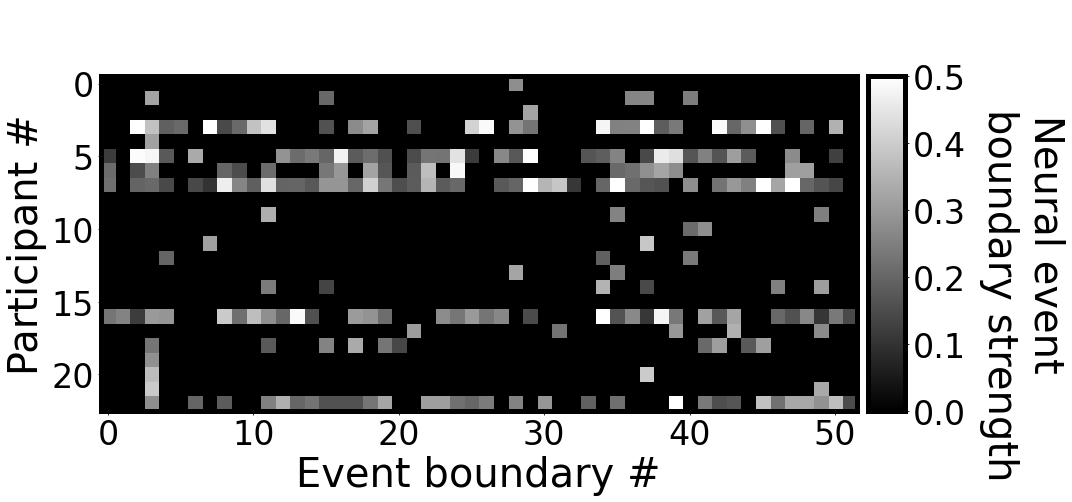

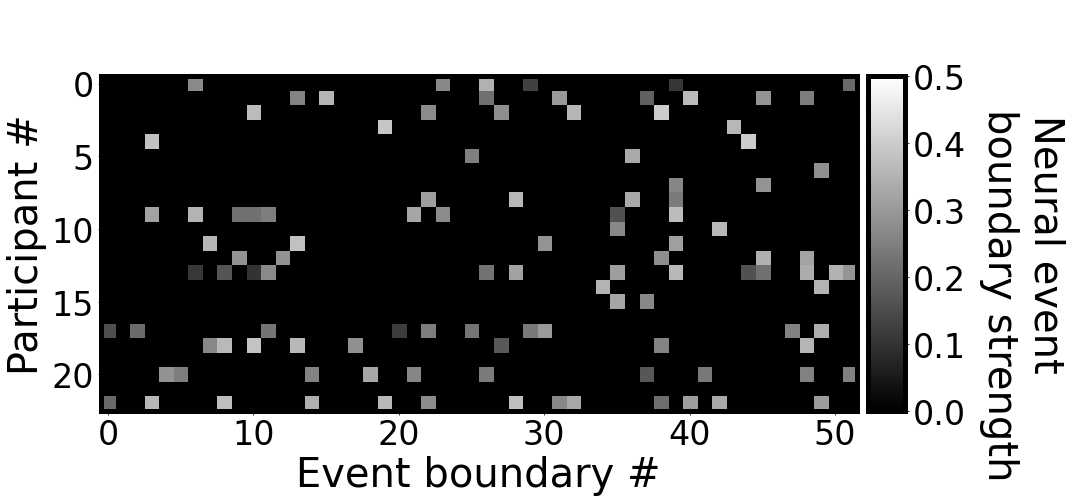

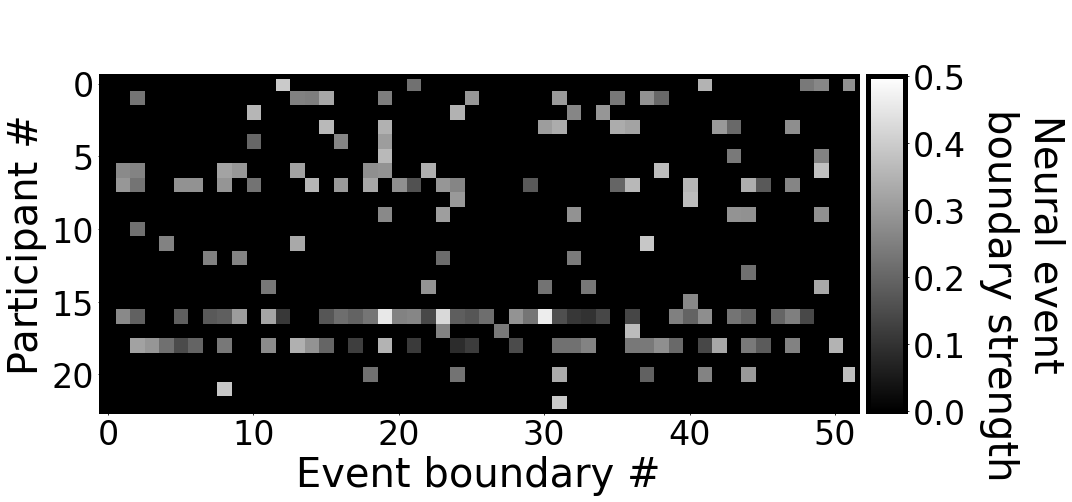

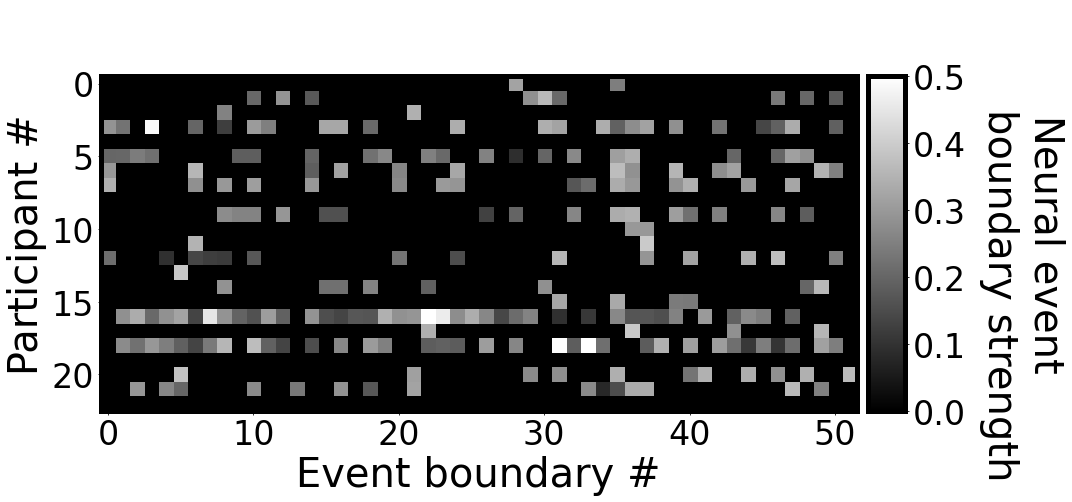

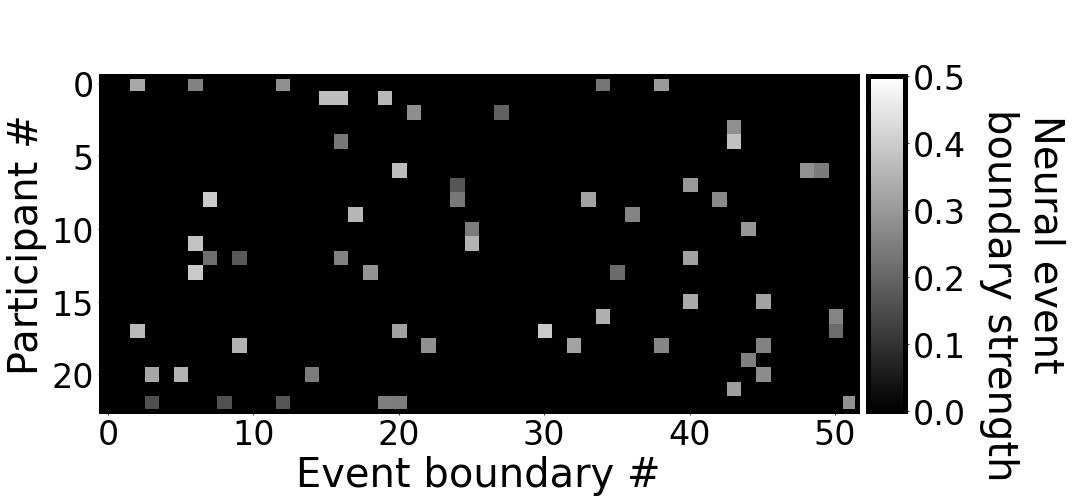

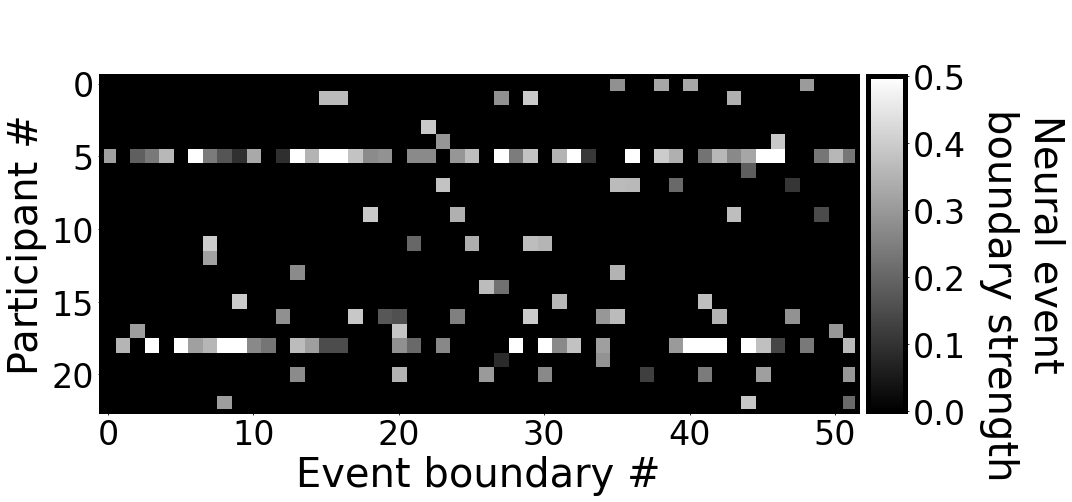

In [13]:
#let's add a figure of all boundaries for all subjects here
if gp<4:
    for roi_in in range(nR):
        fn='pydata/gsbs_bounds_all_m-'+str(gp)+'-'+str(ROIs[roi_in])+'.npy'
        gsbs_bounds_all_m=np.load(fn)
        print(np.max(gsbs_bounds_all_m))
        sn='pydata/view-' + str(ROIs[roi_in]) + '_postSRM_'+str(scut)+'.npy'
        curr_test_obj=np.load(sn)

        f, ax = plt.subplots(1,1, figsize = (15,10))
        im=ax.imshow(gsbs_bounds_all_m, cmap='gray',vmin=0,vmax=0.5) #1
        ax.tick_params(axis='both', which='major',labelsize=fos*2/3,colors='black')
        ax.set_xlabel('Event boundary #',fontsize=fos*.8,color='black')
        ax.set_ylabel('Participant #',fontsize=fos*.8,color='black')
        for axis in ['top','bottom','left','right']:
            ax.spines[axis].set_linewidth(lw9)
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.15)
        cbar=f.colorbar(im, cax=cax)
        cbar.set_label('''Neural event
        boundary strength''',rotation=270,fontsize=fos*.8,labelpad=100,color='black')    
        cbar.ax.tick_params(labelsize=fos*2/3,colors='black') 
        cbar_frame = cbar.ax.spines['outline']
        cbar_frame.set_linewidth(lw9)
        fn="figs/Event_GSBS_bounds_allsubs-"+str(ROIs[roi_in])+"-"+str(raw_or_srm_or_emb)+"-"+str(curr_test_obj.shape[1])+".pdf"
        f.tight_layout()
        plt.savefig(fn, transparent=True)

In [14]:
runthis=0
if runthis:
    for roin in range(nR):
        x,y=ma.masked_invalid(sum_bounds_avg_smooth_tc[:minl,roin]), ma.masked_invalid(all_edges_tc_tr[:minl])
        ccf_ielts = ccf_values(x,y)
        xdat=np.linspace(-(len(x)-1),len(x)-1,(len(x)-1)*2+1)

        if roin==0:
            if gp==4:
                f, ax = plt.subplots(10,10,figsize =(15,15))
            else:
                f, ax = plt.subplots(1,1,figsize =(9,3))
        row,col=roin%10,int(np.floor(roin/10))
        buff=10
        ax[row,col].plot(xdat[len(x)-buff:len(x)+buff],ccf_ielts[len(x)-buff:len(x)+buff])
        ax[row,col].set_ylabel('''Cross-correlation 
            coefficient, avg. group signal''')
        ax[row,col].set_xlabel('TR lag')
        ax[row,col].spines['top'].set_visible(False)
        ax[row,col].spines['right'].set_visible(False) 

        #fit boundaries to each subject, average of collapsed boundaries

In [15]:
runthis=0
if runthis:
    if multsubs:
        for roin in range(nR):
            x,y=ma.masked_invalid(sum_bounds_avg_smooth_tc_a[:minl,roin]), ma.masked_invalid(all_edges_tc_tr[:minl])
            ccf_ielts = ccf_values(x,y)
            xdat=np.linspace(-(len(x)-1),len(x)-1,(len(x)-1)*2+1)
            if roin==0:
                if gp==4:
                    f, ax = plt.subplots(10,10,figsize =(15,15))
                else:
                    f, ax = plt.subplots(1,1,figsize =(9,3))
            row,col=roin%10,int(np.floor(roin/10))
            buff=10
            ax[row,col].plot(xdat[len(x)-buff:len(x)+buff],ccf_ielts[len(x)-buff:len(x)+buff])
            ax[row,col].set_ylabel('''Cross-correlation 
                coefficient, avg. ind. bound.''')
            ax[row,col].set_xlabel('TR lag')
            ax[row,col].spines['top'].set_visible(False)
            ax[row,col].spines['right'].set_visible(False) 

In [16]:
if gp==4:
    yeo_n=np.zeros((nR))
    yeo_nn=['Vis','SomMot','DorsAttn','SalVentAttn','Limbic','Cont','Default']
    '''yeo_nn=['VisCent','VisPeri','SomMotA','SomMotB','DorsAttnA','DorsAttnB',
        'SalVentAttnA','SalVentAttnB','LimbicB','LimbicA','ContA','ContB',
        'ContC','DefaultA','DefaultB','DefaultC','TempPar']'''

    for i in range(nR):
        w=str(ROIs[i])
        for ii in range(len(yeo_nn)):
            if w.find(yeo_nn[ii])>0:
                yeo_n[i]=ii
    print('Yeo network assignments:',yeo_n)

    yeo_n_r=np.zeros((nR))
    qq=np.argsort(yeo_n,kind='mergesort')
    print('Argsort index:',qq)
    yeo_n_r=yeo_n[qq]
    print(yeo_n_r)
    
    ROIs_r=ROIs[qq]
    print(ROIs_r)

In [17]:
## loop over this and create rearr_plot to plot!!
runthis=1
if runthis:
    nperms=1000 #1000
    smooth_agree_s_r,smooth_em_agree_s_r=np.zeros((nperms,nR)),np.zeros((nperms,nR))
    smooth_st_agree_s_r,smooth_emo_agree_s_r=np.zeros((nperms,nR)),np.zeros((nperms,nR))
    smooth_ev1_agree_s_r,smooth_ev2_agree_s_r=np.zeros((nperms,nR)),np.zeros((nperms,nR))
    smooth_agree_a_s_r,smooth_em_agree_a_s_r=np.zeros((nperms,nR)),np.zeros((nperms,nR))
    smooth_st_agree_a_s_r,smooth_emo_agree_a_s_r=np.zeros((nperms,nR)),np.zeros((nperms,nR))
    smooth_ev1_agree_a_s_r,smooth_ev2_agree_a_s_r=np.zeros((nperms,nR)),np.zeros((nperms,nR))

    agree_rank,em_agree_rank,st_agree_rank=np.zeros((nR)),np.zeros((nR)),np.zeros((nR))
    emo_agree_rank,ev1_agree_rank,ev2_agree_rank=np.zeros((nR)),np.zeros((nR)),np.zeros((nR))
    agree_a_rank,em_agree_a_rank,st_agree_a_rank=np.zeros((nR)),np.zeros((nR)),np.zeros((nR))
    emo_agree_a_rank,ev1_agree_a_rank,ev2_agree_a_rank=np.zeros((nR)),np.zeros((nR)),np.zeros((nR))

    for roin in range(nR):
        for i in range(nperms):
            qq=np.random.permutation(minl)
            smooth_agree_s_r[i,roin]=smooth_corr(sum_bounds_avg_smooth_tc[:,roin],all_edges_tc_tr[qq],'',0)
            smooth_em_agree_s_r[i,roin]=smooth_corr(sum_bounds_avg_smooth_tc[:,roin],all_edges_em_tr[qq],'',0)
            smooth_st_agree_s_r[i,roin]=smooth_corr(sum_bounds_avg_smooth_tc[:,roin],all_edges_st_tc_tr[qq],'',0)
            smooth_emo_agree_s_r[i,roin]=smooth_corr(sum_bounds_avg_smooth_tc[:,roin],all_edges_emo_tr[qq],'',0)
            smooth_ev1_agree_s_r[i,roin]=smooth_corr(sum_bounds_avg_smooth_tc[:,roin],evseg_tc1[qq],'',0)
            smooth_ev2_agree_s_r[i,roin]=smooth_corr(sum_bounds_avg_smooth_tc[:,roin],evseg_tc2[qq],'',0)

        agree_rank[roin]=stats.percentileofscore(smooth_agree_s_r[:,roin],smooth_agree_r[roin])
        em_agree_rank[roin]=stats.percentileofscore(smooth_em_agree_s_r[:,roin],smooth_em_agree_r[roin])
        st_agree_rank[roin]=stats.percentileofscore(smooth_st_agree_s_r[:,roin],smooth_st_agree_r[roin])
        emo_agree_rank[roin]=stats.percentileofscore(smooth_emo_agree_s_r[:,roin],smooth_emo_agree_r[roin])
        ev1_agree_rank[roin]=stats.percentileofscore(smooth_ev1_agree_s_r[:,roin],smooth_ev1_agree_r[roin])
        ev2_agree_rank[roin]=stats.percentileofscore(smooth_ev2_agree_s_r[:,roin],smooth_ev2_agree_r[roin])

        #run GSBS on every subject, collapse boundary time courses
        for i in range(nperms):
            qq=np.random.permutation(minl)
            smooth_agree_a_s_r[i,roin]=smooth_corr(sum_bounds_avg_smooth_tc_a[:,roin],all_edges_tc_tr[qq],'',0)
            smooth_em_agree_a_s_r[i,roin]=smooth_corr(sum_bounds_avg_smooth_tc_a[:,roin],all_edges_em_tr[qq],'',0)
            smooth_st_agree_a_s_r[i,roin]=smooth_corr(sum_bounds_avg_smooth_tc_a[:,roin],all_edges_st_tc_tr[qq],'',0)
            smooth_emo_agree_a_s_r[i,roin]=smooth_corr(sum_bounds_avg_smooth_tc_a[:,roin],all_edges_emo_tr[qq],'',0)
            smooth_ev1_agree_a_s_r[i,roin]=smooth_corr(sum_bounds_avg_smooth_tc_a[:,roin],evseg_tc1[qq],'',0)
            smooth_ev2_agree_a_s_r[i,roin]=smooth_corr(sum_bounds_avg_smooth_tc_a[:,roin],evseg_tc2[qq],'',0)

        agree_a_rank[roin]=stats.percentileofscore(smooth_agree_a_s_r[:,roin],smooth_agree_a_r[roin])
        em_agree_a_rank[roin]=stats.percentileofscore(smooth_em_agree_a_s_r[:,roin],smooth_em_agree_a_r[roin])
        st_agree_a_rank[roin]=stats.percentileofscore(smooth_st_agree_a_s_r[:,roin],smooth_st_agree_a_r[roin])
        emo_agree_a_rank[roin]=stats.percentileofscore(smooth_emo_agree_a_s_r[:,roin],smooth_emo_agree_a_r[roin])
        ev1_agree_a_rank[roin]=stats.percentileofscore(smooth_ev1_agree_a_s_r[:,roin],smooth_ev1_agree_a_r[roin])
        ev2_agree_a_rank[roin]=stats.percentileofscore(smooth_ev2_agree_a_s_r[:,roin],smooth_ev2_agree_a_r[roin])

        #read in significance
        thr=97.5
        print(ROIs[roin])
        print('exp')
        sig=(0.5-abs(agree_a_rank[roin]/100-0.5))*2
        print("%.3f" % agree_a_rank[roin])
        print("%.3f" % sig)
        print('eba1')
        sig=(0.5-abs(ev1_agree_a_rank[roin]/100-0.5))*2
        print("%.3f" % ev1_agree_a_rank[roin])
        print("%.3f" % sig)
        print('eba2')
        sig=(0.5-abs(ev2_agree_a_rank[roin]/100-0.5))*2
        print("%.3f" % ev2_agree_a_rank[roin])
        print("%.3f" % sig)
        print("\n")
        

V1
exp
98.600
0.028
eba1
100.000
0.000
eba2
100.000
0.000


vmPFC
exp
98.600
0.028
eba1
100.000
0.000
eba2
100.000
0.000


ang
exp
100.000
0.000
eba1
100.000
0.000
eba2
100.000
0.000


PMC
exp
100.000
0.000
eba1
100.000
0.000
eba2
100.000
0.000


postHC
exp
98.900
0.022
eba1
85.000
0.300
eba2
98.800
0.024


antHC
exp
41.900
0.838
eba1
5.600
0.112
eba2
14.000
0.280




In [18]:
#compute corr w/ size of boundary offset response...
runthis=1 #must run on post/ant in Event_hmm-roi
if runthis:
    fn='pydata/roi_resp_xs_xr-'+str(gp)+'.npy'
    roi_resp_xs_xr=np.load(fn) #this is nS x nR x nEv

    ln='pydata/memo.npy' #matrix w/ info on binary event recall for each sub
    memo=np.load(ln) #this is nS x nEv

    bound_offset_fishz=np.zeros((nS,nR))
    bound_offset_ts,bound_offset_ps=np.zeros((nR)),np.zeros((nR))
    bound_wpl_fishz=np.zeros((nS,nR)) #compute corr w/ wpathl
    bound_wpl_ts,bound_wpl_ps=np.zeros((nR)),np.zeros((nR))
    bound_memo_fishz=np.zeros((nS,nR)) #compute corr w/ wpathl
    bound_memo_ts,bound_memo_ps=np.zeros((nR)),np.zeros((nR))

    for roin in range(nR):
        fn='pydata/gsbs_bounds_all_m-'+str(gp)+'-'+str(ROIs[roin])+'.npy'
        gsbs_bounds_all_m=np.load(fn)
        for s in range(nS):
            bound_offset_fishz[s,roin]=fishr2z(roi_resp_xs_xr[s,roin,:],gsbs_bounds_all_m[s,:])
        res=ttest_1samp(bound_offset_fishz[:,roin],0,nan_policy='omit')
        bound_offset_ts[roin]=res.statistic
        bound_offset_ps[roin]=res.pvalue

        for s in range(nS):
            bound_wpl_fishz[s,roin]=fishr2z(wpathl,gsbs_bounds_all_m[s,:])
        res=ttest_1samp(bound_wpl_fishz[:,roin],0,nan_policy='omit')
        bound_wpl_ts[roin]=res.statistic
        bound_wpl_ps[roin]=res.pvalue

        for s in range(nS):
            bound_memo_fishz[s,roin]=fishr2z(memo[s,:],gsbs_bounds_all_m[s,:])
        res=ttest_1samp(bound_memo_fishz[:,roin],0,nan_policy='omit')
        bound_memo_ts[roin]=res.statistic
        bound_memo_ps[roin]=res.pvalue

/Users/jamesantony/opt/anaconda3/lib/python3.9/site-packages/scipy/stats/stats.py:4023: PearsonRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(PearsonRConstantInputWarning())


IndexError: index 5 is out of bounds for axis 1 with size 5

In [ ]:
def rearr_plots_rank(corrr,rank,yl0,fn):
    fs1=10
    fos=50
    elw=3
    thr=0.05
    nbr=nR+0
    mx=np.max(corrr)
    xt=np.arange(0,nbr,step=1) # set ticks for x-axis

    vl=np.where(np.diff(yeo_n_r)==1)[0]+0.5
    vlp=np.hstack([0,vl])
    vlp=np.hstack([vlp,nbr]) #padded version
    #ym=np.mean(dat,axis=0) #avg x-subs AND x-boundaries for ROI
    ym=rank+0
    if np.max(np.ceil(ym))>1: #if not already a p value (rank instead)
        pvals_buff=((100-(abs(ym-50)+50))*2)/100 #in orig order
    else:
        pvals_buff=ym+0
    
    pvals=np.zeros((nbr)) #in rearranged order
    for i in range(nbr):
        pvals[i]=pvals_buff[qq[i]]
    
    unc=np.where(pvals<thr)[0]
    print('fn:',fn)
    print('unc:',unc)
    print('unc, name: %s' %(ROIs_r[unc]))
    qvals=fdrcorrection(pvals,method='indep')[1] #FDR correction
    #print('qvals',qvals)
    indp=np.where(np.logical_and(qvals<thr,ym>50))[0]
    indn=np.where(np.logical_and(qvals<thr,ym<50))[0]
    qb=np.where(qvals<thr)[0]
    qa=np.where(qvals>=thr)[0]
    print('corr, below threshold: %s' %(qb))
    print('corr, below threshold, name: %s' %(ROIs_r[qb]))
        
    def_only=np.where(yeo_n_r>5)[0]
    #print('pvals def only:',pvals[def_only])
    qvals_do=fdrcorrection(pvals[def_only],method='indep')[1] #FDR correction
    #print('qvals def only:',qvals_do)
    qb_do=np.where(qvals_do<thr)[0]
    qa_do=np.where(qvals_do>=thr)[0]
    print('corr, below & above: def only, %s' %(qb_do))
    
    f, ax = plt.subplots(figsize = (fs1*1.3,fs1*1.3))
    ax.set_xlabel('Parcel, re-arranged by network',fontsize=fos*0.9,color='black')
    ax.set_ylabel(yl0, fontsize = fos*0.9,color='black')
    
    ax.plot(xt[qa],corrr[qq[qa]],'o',color='darkgray',linewidth=2,markersize=8)
    ax.plot(xt[unc],corrr[qq[unc]],'o',color='dimgray',linewidth=2,markersize=8)
    ax.plot(xt[qb],corrr[qq[qb]],'o',color='k',linewidth=2,markersize=8)
    
    #ax.plot(xt,ym[qq],color='k')
    xl1, xl2 = plt.xlim()
    yl1, yl2 = plt.ylim()
    plt.hlines(0,xl1,xl2,color='black',linewidth=2,linestyle='dashed')
    plt.vlines(vlp,yl1,yl2,color='black',linewidth=2,linestyle='dashed')
    plt.xlim(-1,nbr)
    ax.tick_params(axis='both', which='major', labelsize=fos*2/3,colors='black')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False) 
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(4)
    for i in range(len(vlp)-1):
        half=(vlp[i+1]-vlp[i])//2
        ax.text(vlp[i]+half,np.max(corrr)+np.max(corrr)*0.1,yeo_nn[i],fontsize=fos*3/5,ha='center',rotation=90)
    f.tight_layout()
    plt.savefig(fn, transparent=True)
    print('\n')
    #return ym[qq]

In [ ]:
#create rearr_plot_rank!
if gp==4:
    qq=np.argsort(yeo_n,kind='mergesort')
    fn='figs/GSBS_agree-'+str(gp)+'-'+str(test_binary)+'.pdf'
    rearr_plots_rank(smooth_agree_r,agree_rank,'r, neural vs. experimenter-defined',fn)
    fn='figs/GSBS_agree_em-'+str(gp)+'-'+str(test_binary)+'.pdf'
    rearr_plots_rank(smooth_em_agree_r,em_agree_rank,'r, EM boundaries',fn)
    fn='figs/GSBS_agree_st-'+str(gp)+'-'+str(test_binary)+'.pdf'
    rearr_plots_rank(smooth_st_agree_r,st_agree_rank,'r, ST changes',fn)
    fn='figs/GSBS_agree_emo-'+str(gp)+'-'+str(test_binary)+'.pdf'
    rearr_plots_rank(smooth_emo_agree_r,emo_agree_rank,'r, EMO changes',fn)
    fn='figs/GSBS_agree_ev1-'+str(gp)+'-'+str(test_binary)+'.pdf'
    rearr_plots_rank(smooth_ev1_agree_r,ev1_agree_rank,'r, neural vs. EBA1',fn)
    fn='figs/GSBS_agree_ev2-'+str(gp)+'-'+str(test_binary)+'.pdf'
    rearr_plots_rank(smooth_ev2_agree_r,ev2_agree_rank,'r, neural vs. EBA2',fn)

    #corr w/ wpathl
    fn='figs/GSBS_bound_wpathl-'+str(test_binary)+'-'+str(gp)+'.pdf'
    rearr_plots_rank(np.nanmean(bound_wpl_fishz,axis=0),bound_wpl_ps,'''Fisher z, path length vs.
neural event boundaries''',fn)

    fn='figs/GSBS_bound_offset-'+str(test_binary)+'-'+str(gp)+'.pdf'
    rearr_plots_rank(np.nanmean(bound_offset_fishz,axis=0),bound_offset_ps,'''Fisher z, offset response vs.
neural event boundaries''',fn)

    fn='figs/GSBS_bound_memo-'+str(test_binary)+'-'+str(gp)+'.pdf'
    rearr_plots_rank(np.nanmean(bound_memo_fishz,axis=0),bound_memo_ps,'''Fisher z, memory vs.
neural event boundaries''',fn)

In [ ]:
def vplot(d,d1s,d2s,d3s,d4s,d5s,d1s_s,d2s_s,d3s_s,d4s_s,d5s_s,fn): #d5,d6, #plot basic comparisons for >1 exp
    fs,fsz,msz,lw=24,9,125,4
    f,ax=plt.subplots(nrows=1,ncols=1,figsize=(fsz,fsz*3/4)) #
    #cp = sns.color_palette("grays")
    cp2 = sns.color_palette()
    ax=sns.violinplot(data=d, x=lab2, y=lab3, hue=lab1,linewidth=0,inner=None)
    ls=np.linspace(0,nR-1,nR)
    offs=0.16
    if len(d2s)>0:
        ax.scatter(ls-offs*2,d1s,edgecolor=d1s_s,marker='o',s=msz,color=cp2[0],linewidth=lw*3/4)
        ax.scatter(ls-offs,d2s,edgecolor=d2s_s,marker='o',s=msz,color=cp2[1],linewidth=lw*3/4)
        ax.scatter(ls,d3s,edgecolor=d3s_s,marker='o',s=msz,color=cp2[2],linewidth=lw*3/4)
        ax.scatter(ls+offs,d4s,edgecolor=d4s_s,marker='o',s=msz,color=cp2[3],linewidth=lw*3/4)
        ax.scatter(ls+offs*2,d5s,edgecolor=d5s_s,marker='o',s=msz,color=cp2[4],linewidth=lw*3/4)
        ax.hlines(0,0-0.5,nR-1+0.5,linestyles='--',colors='k')
    else:
        ax.scatter(ls-offs*1.7,d1s,edgecolor=d1s_s,marker='o',s=msz,color=cp2[0],linewidth=lw*3/4)
        ax.scatter(ls,d4s,edgecolor=d4s_s,marker='o',s=msz,color=cp2[1],linewidth=lw*3/4)
        ax.scatter(ls+offs*1.7,d5s,edgecolor=d5s_s,marker='o',s=msz,color=cp2[2],linewidth=lw*3/4)
        ax.hlines(0,0-0.5,nR-1+0.5,linestyles='--',colors='k')
    
    ax.set_ylabel(lab3,fontsize=fs*1.5,color='black')
    ax.set_xlabel(lab1,fontsize=fs*1.5,color='black')
    ax.set_ylim([-0.25,0.25])
    ax.tick_params(axis='both', which='major', labelsize=fs,color='black')
    ax.tick_params(axis='x',rotation=30)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    legend = ax.legend(loc="lower center",fontsize=fs*0.9,ncol=3)
    #ax.get_legend().remove()
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(lw) 
    f.tight_layout()
    f.savefig(fn, transparent=True)

def barswarm(d1,d2,d3,d4,d5,d6,lab,yl,fn,exv): #d5,d6, #plot basic comparisons for >1 exp
    fs,fsz,msz,lw=24,9,9,4
    if exv==1:
        xtl=['ROI']
        dat1=pd.DataFrame({'ROI':['V1']*len(d1),lab:d1})
        dat2=pd.DataFrame({'ROI':['mPFC']*len(d2),lab:d2})
        dat3=pd.DataFrame({'ROI':['AG']*len(d3),lab:d3})
        ng=3
        if len(d4)>0:
            dat4=pd.DataFrame({'ROI':['PMC']*len(d4),lab:d4})
            ng=4
            if len(d5)>0:
                dat5=pd.DataFrame({'ROI':['HC']*len(d5),lab:d5})
                ng=5
                if len(d5)>0:
                    dat5=pd.DataFrame({'ROI':['postHC']*len(d5),lab:d5})
                    dat6=pd.DataFrame({'ROI':['antHC']*len(d6),lab:d6})
                    ng=6
        dat = pd.concat([dat1, dat2],ignore_index=True)
        dat = pd.concat([dat, dat3],ignore_index=True)
        if len(d4)>0:
            dat = pd.concat([dat, dat4],ignore_index=True)
            if len(d5)>0:
                dat = pd.concat([dat, dat5],ignore_index=True)
                if len(d6)>0:
                    dat = pd.concat([dat, dat6],ignore_index=True)
         
    f,ax=plt.subplots(nrows=1,ncols=1,figsize=(fsz,fsz*3/4)) #
    cp = sns.color_palette("colorblind")
    join_y="-"
    ax=sns.swarmplot(x=dat['ROI'],y=dat[lab],color='gray',facecolor=None,size=msz,zorder=1)#color=cp
    ax=sns.pointplot(x=dat['ROI'],y=dat[lab],color='k',linestyles=join_y,#palette=cp,#color=cp,#saturation=1,
                     err_kws={'linewidth': lw*2},capsize=.2) #errwidth=lw*2,linestyles=['None']
    ax.set_ylabel(yl,fontsize=fs*1.3,color='black')
    ax.set_xlabel('ROI',fontsize=fs*1.3,color='black')
    ax.set_ylim([-0.3,0.3])
    ax.hlines(0,0-0.5,ng+0.5,linestyles='--',colors='k')
    ax.tick_params(axis='both', which='major', labelsize=fs,color='black')
    ax.tick_params(axis='x',rotation=30)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(lw)
    f.tight_layout()
    f.savefig(fn, transparent=True)

In [ ]:
smooth_agree_a_r[roin]

In [ ]:
#across ROI plots
runthis=0
if runthis:
    wpathl=np.load('pydata/wpathl.npy')
    ROIs = ['V1','vmPFC','ang','PMC','postHC','antHC'] 
    nR=len(ROIs)
    d1s,d2s,d3s,d4s,d5s=np.zeros((nR)),np.zeros((nR)),np.zeros((nR)),np.zeros((nR)),np.zeros((nR))
    if nR==4:
        d1s_s,d2s_s,d3s_s=['0.8','0.8','0.8','0.8'],['0.8','0.8','0.8','0.8'],['0.8','0.8','0.8','0.8']
        d4s_s,d5s_s=['0.8','0.8','0.8','0.8'],['0.8','0.8','0.8','0.8']
    elif nR==5:
        d1s_s,d2s_s,d3s_s=['0.8','0.8','0.8','0.8','0.8'],['0.8','0.8','0.8','0.8','0.8'],['0.8','0.8','0.8','0.8','0.8']
        d4s_s,d5s_s=['0.8','0.8','0.8','0.8','0.8'],['0.8','0.8','0.8','0.8','0.8']
    elif nR==6:
        d1s_s,d2s_s=['0.8','0.8','0.8','0.8','0.8','0.8'],['0.8','0.8','0.8','0.8','0.8','0.8']
        d3s_s,d4s_s=['0.8','0.8','0.8','0.8','0.8','0.8'],['0.8','0.8','0.8','0.8','0.8','0.8']
        d5s_s=['0.8','0.8','0.8','0.8','0.8','0.8']
    bound_wpl_fishz=np.zeros((nS,nR))
    bound_wpl_ts,bound_wpl_ps=np.zeros((nR)),np.zeros((nR))
    dat=pd.DataFrame()  #scrambled data
    datt=pd.DataFrame() #true data
    dat_red=pd.DataFrame() #reduced, for plotting
    for roin in range(nR):
        fn='pydata/gsbs_bounds_all_m-'+str(gp)+'-'+str(ROIs[roin])+'.npy'
        gsbs_bounds_all_m=np.load(fn)
        
        for s in range(nS):
            bound_wpl_fishz[s,roin]=fishr2z(wpathl,gsbs_bounds_all_m[s,:])
        res=ttest_1samp(bound_wpl_fishz[:,roin],0,nan_policy='omit')
        bound_wpl_ts[roin]=res.statistic
        bound_wpl_ps[roin]=res.pvalue
        
        #grab true data, make dataframe
        d1,d2,d3=smooth_agree_r[roin],smooth_st_agree_r[roin],smooth_emo_agree_r[roin]
        d4,d5=smooth_ev1_agree_r[roin],smooth_ev2_agree_r[roin]
        d1s[roin],d2s[roin],d3s[roin]=d1,d2,d3
        d4s[roin],d5s[roin]=d4,d5
        d1r,d2r,d3r=smooth_agree_s_r[:,roin],smooth_st_agree_s_r[:,roin],smooth_emo_agree_s_r[:,roin]
        d4r,d5r=smooth_ev1_agree_s_r[:,roin],smooth_ev2_agree_s_r[:,roin]
        
        #use ind-participant
        d1,d2,d3=smooth_agree_a_r[roin],smooth_st_agree_a_r[roin],smooth_emo_agree_a_r[roin]
        d4,d5=smooth_ev1_agree_a_r[roin],smooth_ev2_agree_a_r[roin]
        d1s[roin],d2s[roin],d3s[roin]=d1,d2,d3
        d4s[roin],d5s[roin]=d4,d5
        d1r,d2r,d3r=smooth_agree_a_s_r[:,roin],smooth_st_agree_a_s_r[:,roin],smooth_emo_agree_a_s_r[:,roin]
        d4r,d5r=smooth_ev1_agree_a_s_r[:,roin],smooth_ev2_agree_a_s_r[:,roin]
        
        #read in significance
        thr=97.5
        print(ROIs[roin])
        print('exp')
        sig=(0.5-abs(stats.percentileofscore(d1r,d1)/100-0.5))*2
        print("%.3f" % sig)
        print('eba1')
        sig=(0.5-abs(stats.percentileofscore(d4r,d4)/100-0.5))*2
        print("%.3f" % sig)
        print('eba2')
        sig=(0.5-abs(stats.percentileofscore(d5r,d5)/100-0.5))*2
        print("%.3f" % sig)
        if stats.percentileofscore(d1r,d1)>thr:
            d1s_s[roin]='k'
        if stats.percentileofscore(d2r,d2)>thr:
            d2s_s[roin]='k'
        if stats.percentileofscore(d3r,d3)>thr:
            d3s_s[roin]='k'
        if stats.percentileofscore(d4r,d4)>thr:
            d4s_s[roin]='k'
        if stats.percentileofscore(d5r,d5)>thr:
            d5s_s[roin]='k'
        
        lab1='Boundary type'
        lab2,lab3='ROI','''Fisher Z, 
measure vs. neural
event boundaries'''
        dat1=pd.DataFrame({lab1:['Exp'],lab2:[ROIs[roin]],lab3:d1})
        dat2=pd.DataFrame({lab1:['ST'],lab2:[ROIs[roin]],lab3:d2})
        dat3=pd.DataFrame({lab1:['EMO'],lab2:[ROIs[roin]],lab3:d3})
        dat4=pd.DataFrame({lab1:['EBA1'],lab2:[ROIs[roin]],lab3:d3})
        dat5=pd.DataFrame({lab1:['EBA2'],lab2:[ROIs[roin]],lab3:d3})
        datt = pd.concat([datt, dat1],ignore_index=True)
        datt = pd.concat([datt, dat2],ignore_index=True)
        datt = pd.concat([datt, dat3],ignore_index=True)
        datt = pd.concat([datt, dat4],ignore_index=True)
        datt = pd.concat([datt, dat5],ignore_index=True)
        
        #grab scrambled data, make dataframe
        dat1=pd.DataFrame({lab1:['Exp']*len(d1r),lab2:[ROIs[roin]]*len(d1r),lab3:d1r})
        dat2=pd.DataFrame({lab1:['ST']*len(d2r),lab2:[ROIs[roin]]*len(d2r),lab3:d2r})
        dat3=pd.DataFrame({lab1:['EMO']*len(d3r),lab2:[ROIs[roin]]*len(d3r),lab3:d3r})
        dat4=pd.DataFrame({lab1:['EBA1']*len(d4r),lab2:[ROIs[roin]]*len(d4r),lab3:d4r})
        dat5=pd.DataFrame({lab1:['EBA2']*len(d5r),lab2:[ROIs[roin]]*len(d5r),lab3:d5r})
        dat = pd.concat([dat, dat1],ignore_index=True)
        dat = pd.concat([dat, dat2],ignore_index=True)
        dat = pd.concat([dat, dat3],ignore_index=True)
        dat = pd.concat([dat, dat4],ignore_index=True)
        dat = pd.concat([dat, dat5],ignore_index=True)
        
        dat1=pd.DataFrame({lab1:['Exp']*len(d1r),lab2:[ROIs[roin]]*len(d1r),lab3:d1r})
        dat_red = pd.concat([dat_red, dat1],ignore_index=True)
        dat_red = pd.concat([dat_red, dat4],ignore_index=True)
        dat_red = pd.concat([dat_red, dat5],ignore_index=True)
        
     #make violin plot of correlation with weighted path length
    
    #fix y axis and save!!!!
    fn='figs/GSBS_boundary_vs_other_measures-'+str(gp)+'-'+str(test_binary)+'.pdf'
    vplot(dat,d1s,d2s,d3s,d4s,d5s,d1s_s,d2s_s,d3s_s,d4s_s,d5s_s,fn)
    
    #make barswarm plot of correlation with weighted path length
    ystr1,fn='''Fisher Z, 
    boundary strength  
    vs. path length''','figs/GSBS_boundary_WPL_indsubs-'+'-'+str(test_binary)+str(gp)+'.pdf'
    if nR==4:
        barswarm(bound_wpl_fishz[:,0],bound_wpl_fishz[:,1],bound_wpl_fishz[:,2],
             bound_wpl_fishz[:,3],[],[],ystr1,ystr1,fn,1)
    elif nR==5:
        barswarm(bound_wpl_fishz[:,0],bound_wpl_fishz[:,1],bound_wpl_fishz[:,2],
             bound_wpl_fishz[:,3],bound_wpl_fishz[:,4],[],ystr1,ystr1,fn,1)
    elif nR==6:
        barswarm(bound_wpl_fishz[:,0],bound_wpl_fishz[:,1],bound_wpl_fishz[:,2],
             bound_wpl_fishz[:,3],bound_wpl_fishz[:,4],bound_wpl_fishz[:,5],ystr1,ystr1,fn,1)

    print('ts: %s, ps: %s' %(bound_wpl_ts,bound_wpl_ps))

In [ ]:
if runthis:
    #fix y axis and save!!!!
    fn='figs/GSBS_boundary_vs_other_measures_red.pdf'
    vplot(dat_red,d1s,[],[],d4s,d5s,d1s_s,[],[],d4s_s,d5s_s,fn)

    stats.percentileofscore(d1r,d1)

In [ ]:
f, ax = plt.subplots(1,1, figsize=(12,6))
ax.plot(wpathl,'k',linewidth=4)
ax.set_xlabel('Event boundary #',fontsize=fos,color='black')
ax.set_ylabel('Path length',fontsize=fos,color='black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False) 
ax.tick_params(axis='both', which='major',labelsize=fos*2/3,colors='black')
for axis in ['bottom','left']:
    ax.spines[axis].set_linewidth(2)
f.tight_layout()    
fn='figs/wpathl.pdf'
#plt.savefig(fn, transparent=True)